# Swedish Rail Electricity Load Profile

This notebook generates an 8,760-hour annual load profile for Swedish rail electricity consumption.

The realistic profile combines three components:
1. **Monthly seasonal multipliers** (winter heating, infrastructure loads)
2. **Day-of-week multipliers** (service schedules)
3. **Hourly multipliers** (double-peak weekday pattern)

Data sources and methodology documented in `README.md`.

## Outputs
- `profile_transport_rail_flat_2024.csv` - Flat baseline profile
- `profile_transport_rail_2024.csv` - Realistic profile with variation

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Configuration
OUTPUT_PATH = Path.cwd().parent  # Export to load_profiles/
DATA_YEAR = 2024

def is_leap_year(year: int) -> bool:
    return year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)

HOURS_IN_YEAR = 8784 if is_leap_year(DATA_YEAR) else 8760

# =============================================================================
# MULTIPLIERS (from README - weighted averages across all rail categories)
# =============================================================================

# Monthly seasonal multipliers (weighted by GWh)
# Winter higher due to: train heating, switch heating, station heating, lighting
SEASONAL_MULTIPLIERS = {
    1: 1.09,   # January - Peak winter
    2: 1.07,   # February
    3: 1.03,   # March
    4: 0.98,   # April
    5: 0.95,   # May
    6: 0.93,   # June
    7: 0.91,   # July - Minimum (summer schedules, minimal heating)
    8: 0.93,   # August
    9: 0.97,   # September
    10: 1.01,  # October
    11: 1.05,  # November
    12: 1.07,  # December
}

# Day-of-week multipliers (weighted by GWh)
# Reflects reduced weekend service, especially Sunday
WEEKDAY_MULTIPLIERS = {
    0: 1.05,  # Monday
    1: 1.07,  # Tuesday (post-COVID peak)
    2: 1.07,  # Wednesday
    3: 1.07,  # Thursday
    4: 1.03,  # Friday
    5: 0.88,  # Saturday
    6: 0.76,  # Sunday - Lowest
}

# Hourly multipliers - WEEKDAY (double-peak "camel" pattern)
# From README: passenger/metro/tram traction weighted with freight and infrastructure
HOURLY_WEEKDAY = np.array([
    0.40,  # 00:00 - Night service
    0.35,  # 01:00
    0.30,  # 02:00 - Minimum
    0.30,  # 03:00 - Minimum
    0.40,  # 04:00
    0.80,  # 05:00 - Early morning
    1.10,  # 06:00 - Ramp up
    1.60,  # 07:00 - Morning peak
    1.65,  # 08:00 - AM PEAK
    1.35,  # 09:00 - Post-peak
    1.20,  # 10:00
    1.00,  # 11:00 - Midday baseline
    1.00,  # 12:00
    1.00,  # 13:00
    1.00,  # 14:00
    1.20,  # 15:00 - Afternoon ramp
    1.55,  # 16:00 - Evening peak begins
    1.70,  # 17:00 - PM PEAK
    1.50,  # 18:00
    1.30,  # 19:00
    1.10,  # 20:00
    0.90,  # 21:00
    0.70,  # 22:00
    0.60,  # 23:00
])

# Hourly multipliers - WEEKEND (flatter, midday peak)
# Later start, no commuter rush, leisure/shopping peak midday-afternoon
HOURLY_WEEKEND = np.array([
    0.35,  # 00:00
    0.30,  # 01:00
    0.25,  # 02:00 - Minimum
    0.25,  # 03:00
    0.30,  # 04:00
    0.45,  # 05:00
    0.60,  # 06:00
    0.75,  # 07:00
    0.90,  # 08:00
    1.05,  # 09:00 - Late start
    1.15,  # 10:00
    1.20,  # 11:00
    1.25,  # 12:00 - Midday peak
    1.25,  # 13:00
    1.25,  # 14:00
    1.25,  # 15:00
    1.20,  # 16:00
    1.15,  # 17:00
    1.10,  # 18:00
    1.00,  # 19:00
    0.85,  # 20:00
    0.70,  # 21:00
    0.55,  # 22:00
    0.45,  # 23:00
])

# Normalize hourly patterns to sum to 24.0 (one day)
HOURLY_WEEKDAY = HOURLY_WEEKDAY / HOURLY_WEEKDAY.sum() * 24
HOURLY_WEEKEND = HOURLY_WEEKEND / HOURLY_WEEKEND.sum() * 24

print(f"Year: {DATA_YEAR} ({'leap' if is_leap_year(DATA_YEAR) else 'normal'})")
print(f"Hours in year: {HOURS_IN_YEAR}")
print(f"\nSeasonal range: {min(SEASONAL_MULTIPLIERS.values()):.2f} - {max(SEASONAL_MULTIPLIERS.values()):.2f}")
print(f"Weekday range: {min(WEEKDAY_MULTIPLIERS.values()):.2f} - {max(WEEKDAY_MULTIPLIERS.values()):.2f}")
print(f"Hourly weekday sum: {HOURLY_WEEKDAY.sum():.2f}")
print(f"Hourly weekend sum: {HOURLY_WEEKEND.sum():.2f}")
print(f"Weekday peak/min: {HOURLY_WEEKDAY.max()/HOURLY_WEEKDAY.min():.1f}x")
print(f"Weekend peak/min: {HOURLY_WEEKEND.max()/HOURLY_WEEKEND.min():.1f}x")

Year: 2024 (leap)
Hours in year: 8784

Seasonal range: 0.91 - 1.09
Weekday range: 0.76 - 1.07
Hourly weekday sum: 24.00
Hourly weekend sum: 24.00
Weekday peak/min: 5.7x
Weekend peak/min: 5.0x


In [2]:
## 1. Generate Flat Profile (Baseline)

# Create flat profile - each hour has equal weight
flat_value = 1.0 / HOURS_IN_YEAR

df_flat = pd.DataFrame({
    'hour': range(HOURS_IN_YEAR),
    'value': flat_value
})

print(f"Flat profile:")
print(f"  Hours: {len(df_flat)}")
print(f"  Value per hour: {flat_value:.10f}")
print(f"  Sum: {df_flat['value'].sum():.10f}")

Flat profile:
  Hours: 8784
  Value per hour: 0.0001138434
  Sum: 1.0000000000


In [3]:
## 2. Generate Realistic Profile

def generate_rail_annual_profile(year: int) -> pd.DataFrame:
    """
    Generate annual rail profile with seasonal, weekly, and hourly variation.

    For each hour:
      raw = HOURLY[hour, is_weekend] × SEASONAL[month] × WEEKDAY[dow]

    Normalize to sum = 1.0
    """
    hours = 8784 if is_leap_year(year) else 8760
    timestamps = pd.date_range(f"{year}-01-01", periods=hours, freq="h")

    raw_values = np.zeros(hours)

    for i, ts in enumerate(timestamps):
        hour = ts.hour
        month = ts.month
        dow = ts.dayofweek  # Monday=0, Sunday=6
        is_weekend = dow >= 5

        # Select hourly pattern based on weekday/weekend
        hourly_mult = HOURLY_WEEKEND[hour] if is_weekend else HOURLY_WEEKDAY[hour]

        # Combine all three multipliers
        raw_values[i] = hourly_mult * SEASONAL_MULTIPLIERS[month] * WEEKDAY_MULTIPLIERS[dow]

    # Normalize to sum = 1.0
    normalized = raw_values / raw_values.sum()

    return pd.DataFrame({
        'timestamp': timestamps,
        'hour': range(hours),
        'value': normalized
    })

# Generate realistic profile
df_realistic = generate_rail_annual_profile(DATA_YEAR)

print(f"Realistic profile:")
print(f"  Hours: {len(df_realistic)}")
print(f"  Sum: {df_realistic['value'].sum():.10f}")
print(f"  Min: {df_realistic['value'].min():.10f}")
print(f"  Max: {df_realistic['value'].max():.10f}")
print(f"  Max/Min ratio: {df_realistic['value'].max() / df_realistic['value'].min():.1f}x")

Realistic profile:
  Hours: 8784
  Sum: 1.0000000000
  Min: 0.0000244236
  Max: 0.0002281442
  Max/Min ratio: 9.3x


## 3. Validate Profile

In [4]:
def validate_rail_profile(df: pd.DataFrame) -> bool:
    """Validate against rail-specific criteria."""
    checks = []

    # 1. Sum equals 1.0
    total = df['value'].sum()
    checks.append(('Sum = 1.0', abs(total - 1.0) < 1e-9, f"{total:.10f}"))

    # 2. All positive
    all_positive = (df['value'] > 0).all()
    checks.append(('All positive', all_positive, f"min={df['value'].min():.2e}"))

    # 3. January > July (seasonal)
    jan = df[df['timestamp'].dt.month == 1]['value'].sum()
    jul = df[df['timestamp'].dt.month == 7]['value'].sum()
    ratio = jan / jul
    checks.append(('January > July', jan > jul, f"ratio={ratio:.2f}"))

    # 4. Weekdays > Weekends
    weekday = df[df['timestamp'].dt.dayofweek < 5]['value'].sum()
    weekend = df[df['timestamp'].dt.dayofweek >= 5]['value'].sum()
    ratio_wd = weekday / weekend
    checks.append(('Weekdays > Weekends', weekday > weekend, f"ratio={ratio_wd:.2f}"))

    # 5. Check for double-peak on weekdays (AM and PM peaks)
    weekday_data = df[df['timestamp'].dt.dayofweek < 5]
    hourly_avg = weekday_data.groupby(weekday_data['timestamp'].dt.hour)['value'].mean()
    am_peak = hourly_avg[7:10].max()  # 7-9 AM
    pm_peak = hourly_avg[16:19].max()  # 4-6 PM
    midday = hourly_avg[11:14].mean()  # 11 AM - 2 PM
    has_double_peak = am_peak > midday and pm_peak > midday
    checks.append(('Double-peak weekday', has_double_peak, f"AM={am_peak:.2e}, PM={pm_peak:.2e}, mid={midday:.2e}"))

    # 6. Weekend flatter than weekday
    weekend_data = df[df['timestamp'].dt.dayofweek >= 5]
    weekend_hourly = weekend_data.groupby(weekend_data['timestamp'].dt.hour)['value'].mean()
    weekday_range = hourly_avg.max() / hourly_avg.min()
    weekend_range = weekend_hourly.max() / weekend_hourly.min()
    checks.append(('Weekend flatter', weekend_range < weekday_range, f"wd={weekday_range:.1f}x, we={weekend_range:.1f}x"))

    print("Validation Results:")
    print("-" * 60)
    for name, passed, detail in checks:
        status = '✓' if passed else '✗'
        print(f"  {status} {name:<25} ({detail})")

    all_passed = all(passed for _, passed, _ in checks)
    print("-" * 60)
    print(f"  {'✓ ALL PASSED' if all_passed else '✗ FAILED'}")

    return all_passed

# Run validation
validate_rail_profile(df_realistic)

Validation Results:
------------------------------------------------------------
  ✓ Sum = 1.0                 (1.0000000000)
  ✓ All positive              (min=2.44e-05)
  ✓ January > July            (ratio=1.20)
  ✓ Weekdays > Weekends       (ratio=3.25)
  ✓ Double-peak weekday       (AM=2.01e-04, PM=2.07e-04, mid=1.22e-04)
  ✓ Weekend flatter           (wd=5.7x, we=5.0x)
------------------------------------------------------------
  ✓ ALL PASSED


True

## 4. Visualize Results

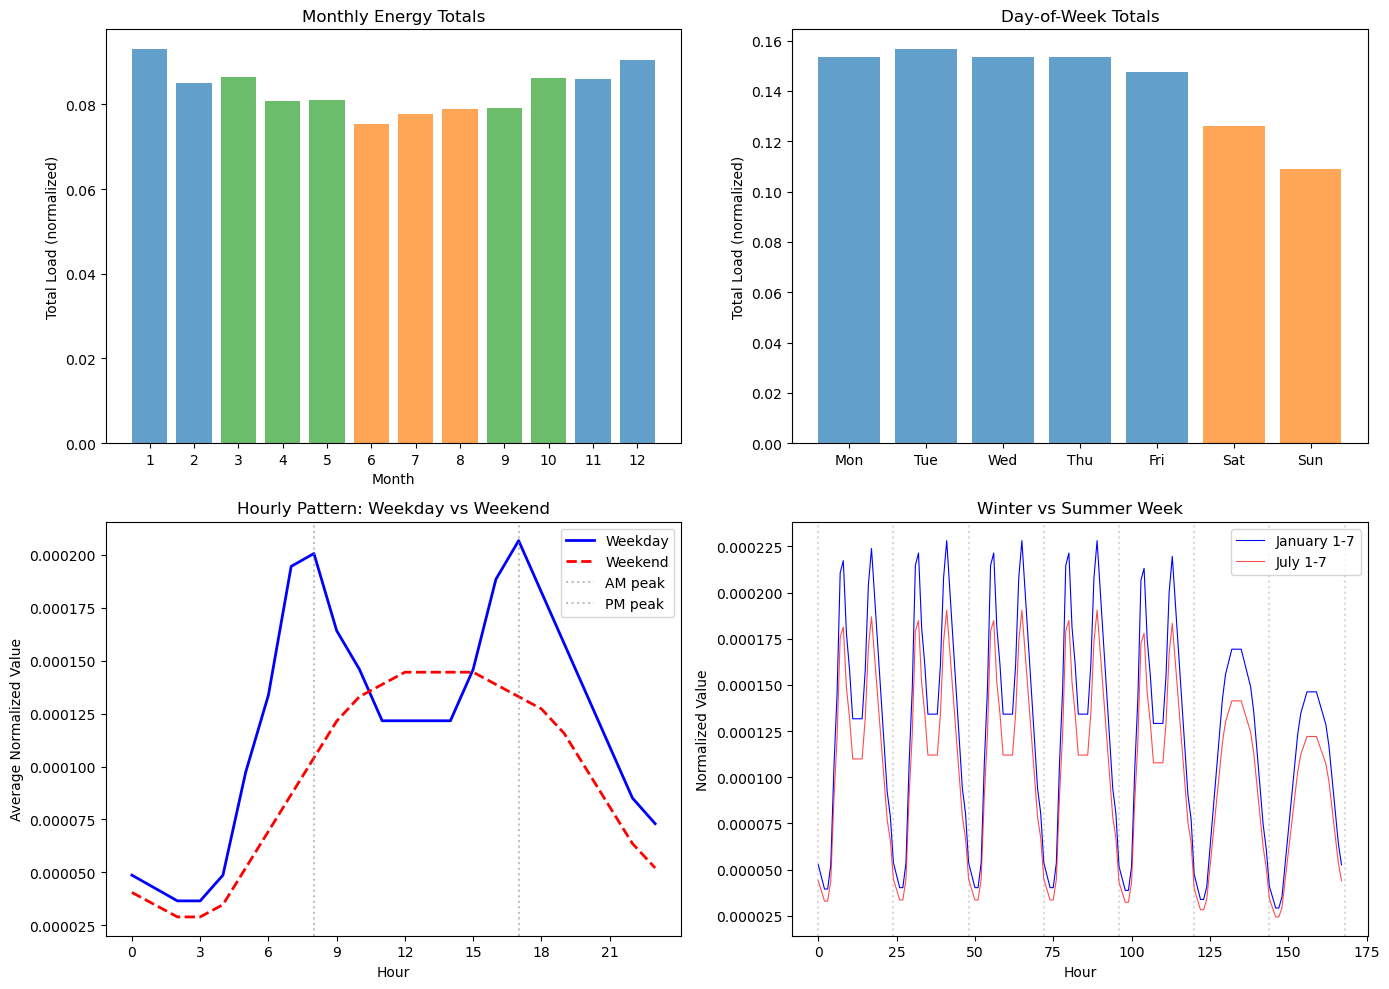


Seasonal comparison:
  January total:  0.0930
  July total:     0.0777
  Jan/Jul ratio:  1.20x

Weekday/Weekend comparison:
  Weekday total (Mon-Fri): 0.7648
  Weekend total (Sat-Sun): 0.2352
  Weekday/Weekend ratio:   1.30x


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Monthly totals
ax1 = axes[0, 0]
monthly = df_realistic.groupby(df_realistic['timestamp'].dt.month)['value'].sum()
colors = ['#1f77b4' if m in [1, 2, 11, 12] else '#ff7f0e' if m in [6, 7, 8] else '#2ca02c' for m in monthly.index]
ax1.bar(monthly.index, monthly.values, color=colors, alpha=0.7)
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Load (normalized)')
ax1.set_title('Monthly Energy Totals')
ax1.set_xticks(range(1, 13))

# 2. Day-of-week totals
ax2 = axes[0, 1]
daily = df_realistic.groupby(df_realistic['timestamp'].dt.dayofweek)['value'].sum()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = ['#1f77b4' if i < 5 else '#ff7f0e' for i in range(7)]
ax2.bar(days, daily.values, color=colors, alpha=0.7)
ax2.set_ylabel('Total Load (normalized)')
ax2.set_title('Day-of-Week Totals')

# 3. Average hourly pattern - Weekday vs Weekend
ax3 = axes[1, 0]
weekday_data = df_realistic[df_realistic['timestamp'].dt.dayofweek < 5]
weekend_data = df_realistic[df_realistic['timestamp'].dt.dayofweek >= 5]
weekday_hourly = weekday_data.groupby(weekday_data['timestamp'].dt.hour)['value'].mean()
weekend_hourly = weekend_data.groupby(weekend_data['timestamp'].dt.hour)['value'].mean()

ax3.plot(range(24), weekday_hourly.values, 'b-', linewidth=2, label='Weekday')
ax3.plot(range(24), weekend_hourly.values, 'r--', linewidth=2, label='Weekend')
ax3.axvline(x=8, color='gray', linestyle=':', alpha=0.5, label='AM peak')
ax3.axvline(x=17, color='gray', linestyle=':', alpha=0.5, label='PM peak')
ax3.set_xlabel('Hour')
ax3.set_ylabel('Average Normalized Value')
ax3.set_title('Hourly Pattern: Weekday vs Weekend')
ax3.legend()
ax3.set_xticks(range(0, 24, 3))

# 4. Sample week comparison (January vs July)
ax4 = axes[1, 1]
jan_week = df_realistic[(df_realistic['timestamp'].dt.month == 1) & 
                         (df_realistic['timestamp'].dt.day <= 7)]
jul_week = df_realistic[(df_realistic['timestamp'].dt.month == 7) & 
                         (df_realistic['timestamp'].dt.day <= 7)]

ax4.plot(range(len(jan_week)), jan_week['value'].values, 'b-', linewidth=0.8, label='January 1-7')
ax4.plot(range(len(jul_week)), jul_week['value'].values, 'r-', linewidth=0.8, alpha=0.7, label='July 1-7')
for d in range(8):
    ax4.axvline(x=d*24, color='gray', linestyle=':', alpha=0.3)
ax4.set_xlabel('Hour')
ax4.set_ylabel('Normalized Value')
ax4.set_title('Winter vs Summer Week')
ax4.legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nSeasonal comparison:")
print(f"  January total:  {monthly[1]:.4f}")
print(f"  July total:     {monthly[7]:.4f}")
print(f"  Jan/Jul ratio:  {monthly[1]/monthly[7]:.2f}x")

print(f"\nWeekday/Weekend comparison:")
weekday_total = daily[:5].sum()
weekend_total = daily[5:].sum()
print(f"  Weekday total (Mon-Fri): {weekday_total:.4f}")
print(f"  Weekend total (Sat-Sun): {weekend_total:.4f}")
print(f"  Weekday/Weekend ratio:   {(weekday_total/5)/(weekend_total/2):.2f}x")

## 5. Export Profiles

In [6]:
# Export FLAT profile (baseline)
flat_file = OUTPUT_PATH / f'profile_transport_rail_flat_{DATA_YEAR}.csv'
df_flat.to_csv(flat_file, index=False)
print(f"Exported flat profile: {flat_file.name}")
print(f"  Rows: {len(df_flat)}")

# Export REALISTIC profile (with variation)
realistic_file = OUTPUT_PATH / f'profile_transport_rail_{DATA_YEAR}.csv'
df_export = df_realistic[['hour', 'value']].copy()
df_export.to_csv(realistic_file, index=False)
print(f"\nExported realistic profile: {realistic_file.name}")
print(f"  Rows: {len(df_export)}")

# Verify
print(f"\nVerification:")
for file in [flat_file, realistic_file]:
    df_verify = pd.read_csv(file)
    print(f"  {file.name}: {len(df_verify)} rows, sum={df_verify['value'].sum():.10f}")

# List all rail profile files
print(f"\nRail profile files in {OUTPUT_PATH.name}/:")
for f in sorted(OUTPUT_PATH.glob('profile_transport_rail*.csv')):
    print(f"  {f.name}")

Exported flat profile: profile_transport_rail_flat_2024.csv
  Rows: 8784

Exported realistic profile: profile_transport_rail_2024.csv
  Rows: 8784

Verification:
  profile_transport_rail_flat_2024.csv: 8784 rows, sum=1.0000000000
  profile_transport_rail_2024.csv: 8784 rows, sum=1.0000000000

Rail profile files in load_profiles/:
  profile_transport_rail_2024.csv
  profile_transport_rail_flat_2024.csv


## 6. Export Patterns for Multi-Year Extension

Export the underlying patterns (hourly, weekday, monthly) as JSON for use with `extend_from_pattern()`.

Note: Rail has separate weekday/weekend hourly patterns, so we export both.

In [7]:
import json

# Prepare patterns for JSON export

# 1. Hourly patterns (normalized to sum=1.0 each)
# Rail has separate weekday and weekend patterns
hourly_weekday_norm = (HOURLY_WEEKDAY / HOURLY_WEEKDAY.sum()).tolist()
hourly_weekend_norm = (HOURLY_WEEKEND / HOURLY_WEEKEND.sum()).tolist()
print(f"Hourly weekday: sum={sum(hourly_weekday_norm):.4f}")
print(f"Hourly weekend: sum={sum(hourly_weekend_norm):.4f}")

# 2. Weekday multipliers (7 values, Mon-Sun, relative to mean)
weekday_values = [WEEKDAY_MULTIPLIERS[i] for i in range(7)]
weekday_mean = sum(weekday_values) / 7
weekday_mult_normalized = [v / weekday_mean for v in weekday_values]
print(f"Weekday multipliers: {[round(v, 4) for v in weekday_mult_normalized]}")
print(f"  Sum: {sum(weekday_mult_normalized):.2f} (should be ~7.0)")

# 3. Monthly multipliers (12 values, relative to mean)
monthly_values = [SEASONAL_MULTIPLIERS[m] for m in range(1, 13)]
monthly_mean = sum(monthly_values) / 12
monthly_mult_normalized = [v / monthly_mean for v in monthly_values]
print(f"Monthly multipliers: {[round(v, 4) for v in monthly_mult_normalized]}")
print(f"  Sum: {sum(monthly_mult_normalized):.2f} (should be ~12.0)")

# Create patterns dict - note the hourly_weekday/hourly_weekend structure
patterns = {
    'hourly_weekday': hourly_weekday_norm,  # 24 values for Mon-Fri
    'hourly_weekend': hourly_weekend_norm,  # 24 values for Sat-Sun
    'weekday': weekday_mult_normalized,     # 7 values (Mon-Sun)
    'monthly': monthly_mult_normalized,     # 12 values
    'source_year': DATA_YEAR,
    'description': 'Swedish rail electricity load patterns (passenger, freight, infrastructure, metro, tram)',
    'notes': 'Uses separate hourly patterns for weekday (double-peak) and weekend (flat midday)'
}

# Export to JSON
pattern_file = OUTPUT_PATH / 'profile_transport_rail_patterns.json'
with open(pattern_file, 'w') as f:
    json.dump(patterns, f, indent=2)

print(f"\nPatterns exported to: {pattern_file}")
print(f"Use with extend_from_pattern() for multi-year timeseries generation.")
print(f"\nNote: Rail patterns use hourly_weekday/hourly_weekend instead of single hourly array.")

Hourly weekday: sum=1.0000
Hourly weekend: sum=1.0000
Weekday multipliers: [1.0606, 1.0808, 1.0808, 1.0808, 1.0404, 0.8889, 0.7677]
  Sum: 7.00 (should be ~7.0)
Monthly multipliers: [1.0909, 1.0709, 1.0309, 0.9808, 0.9508, 0.9308, 0.9108, 0.9308, 0.9708, 1.0108, 1.0509, 1.0709]
  Sum: 12.00 (should be ~12.0)

Patterns exported to: /home/viktor/code/behovskartan/generator/input/load_profiles/profile_transport_rail_patterns.json
Use with extend_from_pattern() for multi-year timeseries generation.

Note: Rail patterns use hourly_weekday/hourly_weekend instead of single hourly array.
